# Nonlinear Equations

examples

In [1]:
import numpy as np
from scipy import linalg as la
import scipy.optimize as opt
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
np.set_printoptions(suppress=True, precision=6)  # 抑制科学计数法，小数位6位

def sign(x):
    s = np.sign(x)
    return s if s else 1

[[ 1.       -2.365884  3.        8.43552 ]
 [ 1.       -2.365884  2.        0.36281 ]
 [ 1.5      -1.73998   2.        0.36281 ]
 [ 1.75     -0.873444  2.        0.36281 ]
 [ 1.875    -0.300718  2.        0.36281 ]
 [ 1.875    -0.300718  1.9375    0.019849]
 [ 1.90625  -0.143255  1.9375    0.019849]
 [ 1.921875 -0.062406  1.9375    0.019849]
 [ 1.929688 -0.021454  1.9375    0.019849]
 [ 1.933594 -0.000846  1.9375    0.019849]
 [ 1.933594 -0.000846  1.935547  0.009491]
 [ 1.933594 -0.000846  1.93457   0.00432 ]
 [ 1.933594 -0.000846  1.934082  0.001736]
 [ 1.933594 -0.000846  1.933838  0.000445]
 [ 1.933716 -0.000201  1.933838  0.000445]
 [ 1.933716 -0.000201  1.933777  0.000122]
 [ 1.933746 -0.000039  1.933777  0.000122]
 [ 1.933746 -0.000039  1.933762  0.000041]
 [ 1.933746 -0.000039  1.933754  0.000001]
 [ 1.93375  -0.000019  1.933754  0.000001]
 [ 1.933752 -0.000009  1.933754  0.000001]
 [ 1.933753 -0.000004  1.933754  0.000001]]


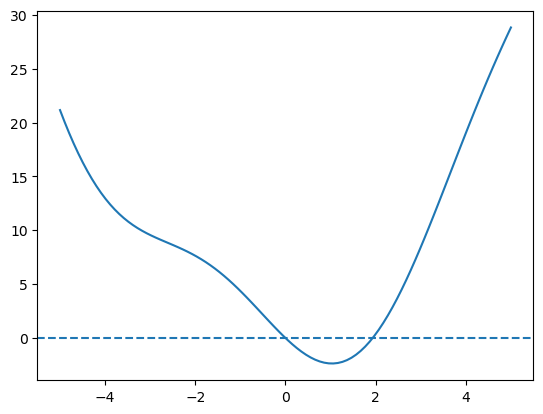

In [2]:
# 5.7
def f(x):
    return x ** 2 - 4 * np.sin(x)


def bisect(f, a, b, tol=1e-6):
    fa, fb = f(a), f(b)
    history = [[a, fa, b, fb]]
    while b - a > tol:
        m = a + (b - a) / 2
        fm = f(m)
        if sign(fa) == sign(f(m)):
            a, fa = m, fm
        else:
            b, fb = m, fm
        history.append([a, fa, b, fb])
    return a, np.array(history)


x = np.linspace(-5, 5, 100)
y = f(x)
plt.plot(x, y)
plt.axhline(linestyle='--')


x, history = bisect(f, 1, 3)
print(history)

In [3]:
# 5.10
def fprime(x):
    return 2 * x - 4 * np.cos(x)

    
def newton(f, fprime, x, tol=1e-6, n=1000):
    history = []
    for _ in range(n):
        fx, fprimex = f(x), fprime(x)
        h = - fx / fprimex
        history.append([x, fx, fprimex, h])
        if abs(h) < tol:
            break
        x += h
    return x, np.array(history)


x, history = newton(f, fprime, 3)
print(history)

[[ 3.        8.43552   9.95997  -0.846942]
 [ 2.153058  1.294773  6.505772 -0.199019]
 [ 1.954039  0.108439  5.403795 -0.020067]
 [ 1.933972  0.001152  5.28892  -0.000218]
 [ 1.933754  0.        5.28767  -0.      ]]


In [4]:
# 5.11
def f1(x):
    return x ** 2 - 1

def f1_prime(x):
    return 2 * x

def f2(x):
    return x ** 2 - 2 * x + 1

def f2_prime(x):
    return 2 * x - 2


_, history = newton(f1, f1_prime, 2)
print(history, '\n')

_, history = newton(f2, f2_prime, 2)
print(history)

[[ 2.        3.        4.       -0.75    ]
 [ 1.25      0.5625    2.5      -0.225   ]
 [ 1.025     0.050625  2.05     -0.024695]
 [ 1.000305  0.00061   2.00061  -0.000305]
 [ 1.        0.        2.       -0.      ]] 

[[ 2.        1.        2.       -0.5     ]
 [ 1.5       0.25      1.       -0.25    ]
 [ 1.25      0.0625    0.5      -0.125   ]
 [ 1.125     0.015625  0.25     -0.0625  ]
 [ 1.0625    0.003906  0.125    -0.03125 ]
 [ 1.03125   0.000977  0.0625   -0.015625]
 [ 1.015625  0.000244  0.03125  -0.007812]
 [ 1.007812  0.000061  0.015625 -0.003906]
 [ 1.003906  0.000015  0.007812 -0.001953]
 [ 1.001953  0.000004  0.003906 -0.000977]
 [ 1.000977  0.000001  0.001953 -0.000488]
 [ 1.000488  0.        0.000977 -0.000244]
 [ 1.000244  0.        0.000488 -0.000122]
 [ 1.000122  0.        0.000244 -0.000061]
 [ 1.000061  0.        0.000122 -0.000031]
 [ 1.000031  0.        0.000061 -0.000015]
 [ 1.000015  0.        0.000031 -0.000008]
 [ 1.000008  0.        0.000015 -0.000004]
 [ 1.000

In [5]:
# 5.12
def secant(f, x0, x1, tol=1e-6, n=1000):
    fx0, fx1 = f(x0), f(x1)
    history = [[x0, fx0, np.nan]]
    for _ in range(n):
        h = - fx1 * (x1 - x0) / (fx1 - fx0)
        history.append([x1, fx1, h])
        if abs(h) < tol:
            break
        x0, fx0, x1, fx1 = x1, fx1, x1+h, f(x1+h)
    return x1, np.array(history)

_, history = secant(f, 1, 3)
print(history)

[[ 1.       -2.365884       nan]
 [ 3.        8.43552  -1.56193 ]
 [ 1.43807  -1.896774  0.286735]
 [ 1.724805 -0.977706  0.305029]
 [ 2.029833  0.534304 -0.107789]
 [ 1.922044 -0.061523  0.01113 ]
 [ 1.933174 -0.003065  0.000583]
 [ 1.933757  0.00002  -0.000004]
 [ 1.933754 -0.        0.      ]]


In [6]:
# 5.13
def inverse_interpolation(f, a, b, c, tol=1e-6, n=1000):
    fa,  fb, fc = f(a), f(b), f(c)
    history = [
        [a, fa, np.nan],
        [b, fb, np.nan],
        [c, fc, np.nan],
    ]
    
    for _ in range(n):
        u, v, w = fb / fc, fb / fa, fa / fc
        p = v * (w * (u - w) * (c - b) - (1 - u) * (b - a))
        q = (w - 1) * (u - 1) * (v - 1)
        h = p / q
        if abs(h) < tol:
            break
        a, b, c = b, b + h, a
        fa, fb, fc = fb, f(b), fa
        history.append([b, fb, h])

    return b, np.array(history)


_, history = inverse_interpolation(f, 1, 2, 3)
print(history)

[[ 1.       -2.365884       nan]
 [ 2.        0.36281        nan]
 [ 3.        8.43552        nan]
 [ 1.886318 -0.244343 -0.113682]
 [ 1.939558  0.030787  0.05324 ]
 [ 1.933742 -0.00006  -0.005815]
 [ 1.933754  0.        0.000011]]


In [7]:
# 5.14
def linear_fractional_interpolation(f, a, b, c, tol=1e-6, n=1000):
    fa, fb, fc = f(a), f(b), f(c)
    history = [
        [a, fa, np.nan],
        [b, fb, np.nan],
    ]
    for _ in range(n):
        h = (a - c) * (b - c) * (fa - fb) * fc / ((a - c) * (fc - fb) * fa - (b - c) * (fc - fa) * fb)
        history.append([c, fc, h])
        if abs(h) < tol:
            break
        a, b, c = b, c, c + h
        fa, fb, fc = fb, fc, f(c)
    return c, np.array(history)


_, history = linear_fractional_interpolation(f, 1, 2, 3)
print(history)

# (array([1.      , 2.      , 3.      , 1.906953, 1.933351, 1.933756,
#         1.933754]),
#  array([-2.365884,  0.36281 ,  8.43552 , -0.139647, -0.002131,  0.000013,
#          0.000013]),
#  array([-1.093047,  0.026398,  0.000406, -0.000003]))

[[ 1.       -2.365884       nan]
 [ 2.        0.36281        nan]
 [ 3.        8.43552  -1.093047]
 [ 1.906953 -0.139647  0.026398]
 [ 1.933351 -0.002131  0.000406]
 [ 1.933756  0.000013 -0.000003]
 [ 1.933754  0.       -0.      ]]


In [53]:
# 5.16
def f(x):
    return np.array([
        x[0] + 2 * x[1] - 2,
        x[0] ** 2 + 4 * x[1] ** 2 - 4,
    ])


def broyden(f, x, B=None, args=(), n=1000, tol=1e-6):
    history = []
    B = (B if B is not None else np.eye(len(x))).astype(float)
    fx0 = f(x, *args)

    for _ in range(n):
        h = la.solve(B, -fx0)
        history.append(np.hstack([x, [la.norm(h)]]))
        if la.norm(h) < 1e-6:
            break
        x += h
        fx1 = f(x, *args)
        y = fx1 - fx0
        fx0 = fx1
        B += np.outer((y - B @ h), h) / (h @ h)

    return x, np.array(history)


broyden(f, [1, 2], n=1000)

(array([-0.,  1.]),
 array([[  1.      ,   2.      ,  13.341664],
        [ -2.      , -11.      ,  14.293608],
        [ -2.766733,   3.273028,   6.151157],
        [ -8.168411,   6.215579,   8.579291],
        [ -0.964935,   1.555733,   0.309685],
        [ -0.721671,   1.36409 ,   0.271453],
        [ -0.482406,   1.235873,   0.321803],
        [ -0.193022,   1.095112,   0.182868],
        [ -0.028874,   1.014513,   0.032374],
        [  0.000063,   0.999999,   0.000221],
        [  0.000249,   0.999878,   0.000117],
        [  0.000144,   0.99993 ,   0.000161],
        [ -0.      ,   1.      ,   0.      ]]))

exercises

In [9]:
# 5.7
# function is lam(x) - 1.5
# (a)
a = np.sqrt(np.pi)
A = np.vander([.5, 1, 1.5], increasing=True)
b = np.array([a - 1.5, -.5, a / 2 - 1.5])
x = la.solve(A, b)
p = Polynomial(x)
print(p.roots())

# (b)
A = np.vander([a - 1.5, -0.5, a / 2 - 1.5], increasing=True)
b = np.array([.5, 1, 1.5])
y = la.solve(A, b)
print(Polynomial(y)(0))

# (c)
def f(x):
    if x == .5:
        return a - 1.5
    elif x == 1:
        return -.5
    elif x == 1.5:
        return a / 2 - 1.5


linear_fractional_interpolation(f, .5, 1, 1.5, 1) # 0.561369

[0.634447 2.038281]
0.10031828690509814


(1.5,
 array([[ 0.5     ,  0.272454,       nan],
        [ 1.      , -0.5     ,       nan],
        [ 1.5     , -0.613773, -0.938631]]))

computer problems

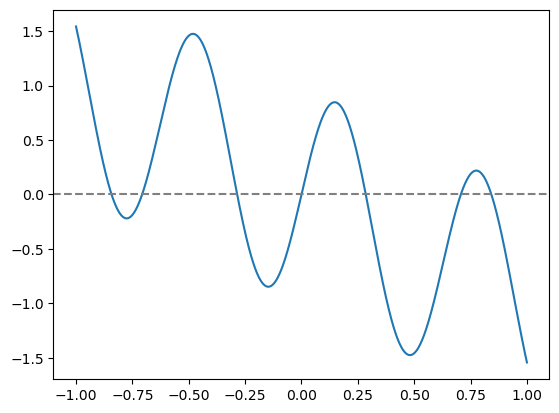

In [10]:
# 5.1
def f(x):
    return np.sin(10 * x) - x

x = np.linspace(-1, 1, 1000)
plt.plot(x, f(x))
plt.axhline(0, color='gray', linestyle='--')

In [11]:
# library routine
def fprime(x):
    return 10 * np.cos(10 * x) - 1

for x0 in -1, -.7, -.3, 0.1, .25, .49, .65, 1:
    print(opt.root_scalar(f, x0=x0, fprime=fprime, method='newton').root)

-0.8423203932360491
-0.7068174358095818
-0.28523418944500917
0.0
0.28523418944500917
0.7068174358095817
0.7068174358095818
0.8423203932360491


17.008667027361085
[ 0.136667  0.188448  0.263102  0.373877  0.545097  0.825839  1.328455
  2.359538  5.001857 15.008667]
2.000000052718759
[0.073644 0.054491 0.040459 0.030117 0.022462 0.016776 0.012543 0.009385
 0.007026 0.005263 0.003943 0.002955 0.002215 0.001661 0.001245 0.000934
 0.0007   0.000525 0.000394 0.000295 0.000221 0.000166 0.000125 0.000093
 0.00007  0.000053 0.000039 0.00003  0.000022 0.000017 0.000012 0.000009
 0.000007 0.000005 0.000004 0.000003 0.000002 0.000002 0.000001 0.000001
 0.000001 0.000001 0.       0.       0.       0.       0.       0.
 0.       0.      ]
2.0000000054186042
[0.047619 0.023256 0.011494 0.005714 0.002849 0.001422 0.000711 0.000355
 0.000178 0.000089 0.000044 0.000022 0.000011 0.000006 0.000003 0.000001
 0.000001 0.       0.       0.       0.       0.       0.       0.      ]
2.000000004665074
[0.008333 0.000068 0.      ]
2.0000000000732485
[2.272727 0.931446 0.303047 0.057181 0.002934 0.000009 0.      ]
[0.180328 0.349297 0.622628 0.897375 0

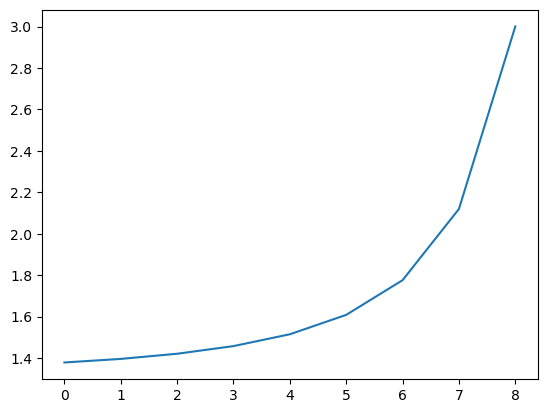

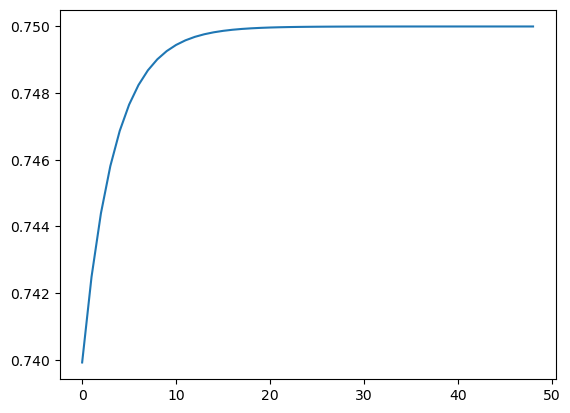

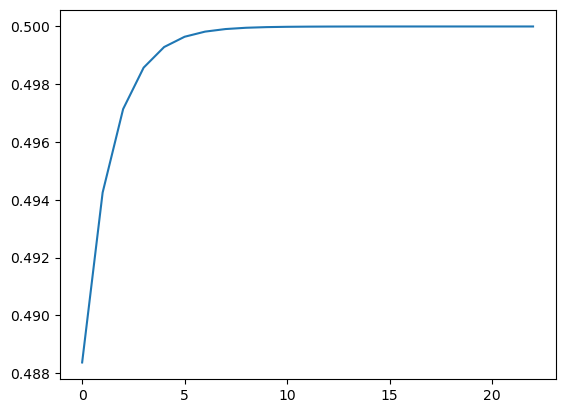

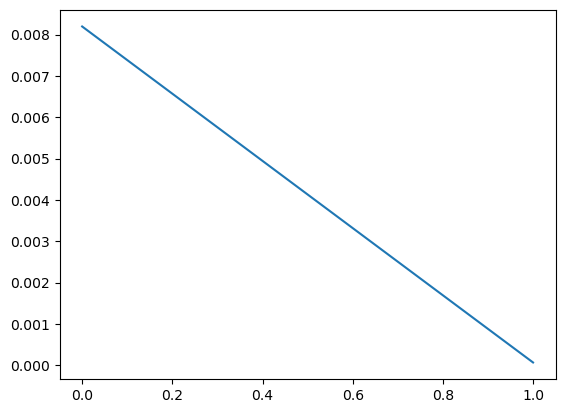

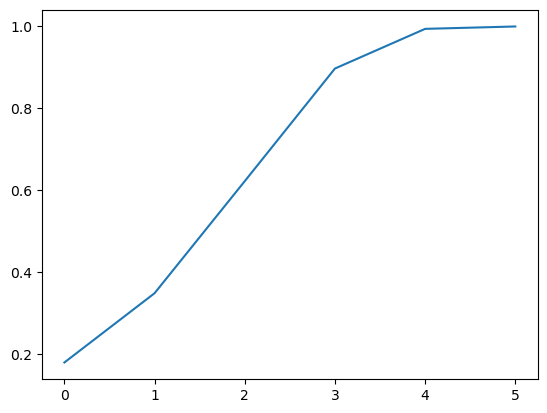

In [12]:
# 5.2
# (b)
def fixed_point(f, x0, x_true=None, n=100):
    error = []
    for i in range(n):
        x1 = f(x0)
        if x1 == x_true or np.isnan(x1):
            break
        error.append(abs(x1 - (x_true if x_true else x0)))
        if error[-1] < 1e-8:
            break

        x0 = x1
    return x1, np.array(error)


def g1(x):
    return (x * x + 2) / 3


def g2(x):
    return np.sqrt(3 * x - 2)


def g3(x):
    return 3 - 2 / x


def g4(x):
    return (x * x - 2) / (2 * x - 3)


for f, n in (g1, 10), (g2, 50), (g3, 50), (g4, 10):
    x, error = fixed_point(f, x0=2.1, x_true=2, n=n)
    print(x)
    print(error)
    plt.figure()
    error_linear_ratio = np.exp(np.diff(np.log(error)))
    plt.plot(error_linear_ratio)


x, error = fixed_point(f, x0=7, x_true=2, n=n)
print(x)
print(error)

plt.figure()
error_quadratic_ratio = np.exp(np.log(error[1:]) - 2 * np.log(error[:-1]))
print(error_quadratic_ratio)
plt.plot(error_quadratic_ratio)

[ 2.094551 -0.000004  2.094552  0.000006]

[ 0.567143  0.       -1.567143  0.      ]

[ 1.114156 -0.000001  0.000001]

[ 1.000004  0.       -0.000006]

[ 0.999996  0.       -0.      ]



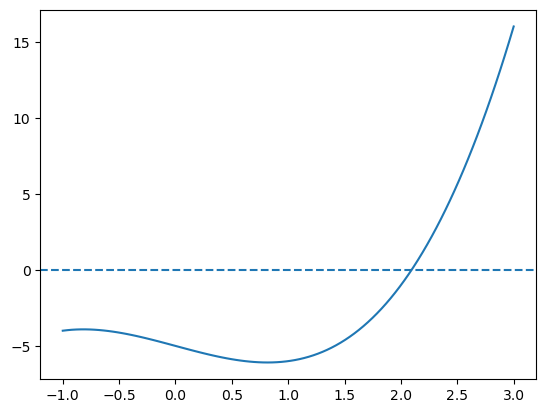

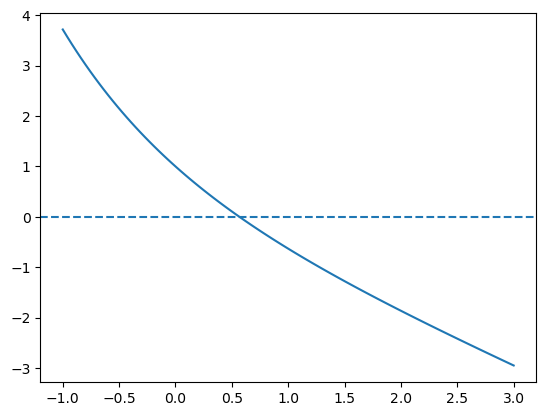

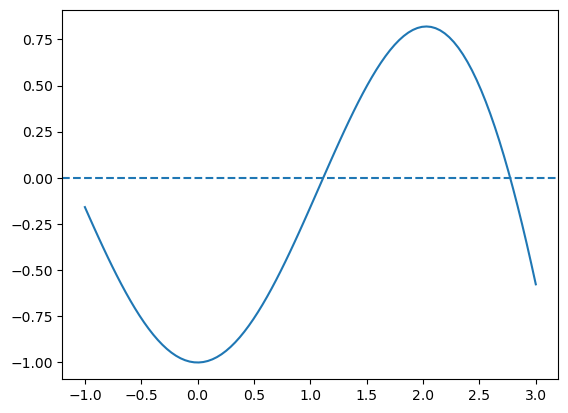

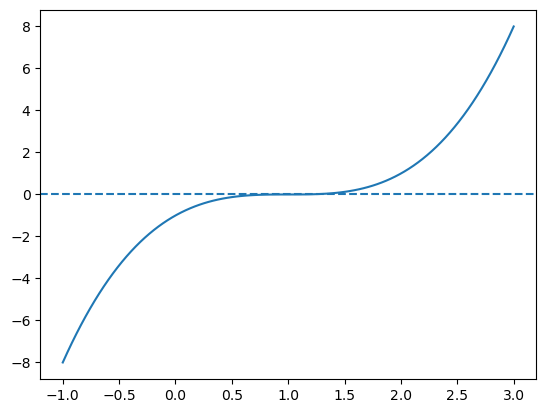

In [13]:
# 5.3
# (a)
def fa(x):
    return x ** 3 - 2 * x - 5


x = np.linspace(-1, 3, 100)
plt.plot(x, fa(x))
plt.axhline(linestyle='--')
_, history = bisect(fa, 1.5, 2.5)
print(history[-1])
print()

# (b)
def fb(x):
    return np.exp(-x) - x

def fb_prime(x):
    return - np.exp(-x) - 1

plt.figure()
x = np.linspace(-1, 3, 100)
plt.plot(x, fb(x))
plt.axhline(linestyle='--')

_, history = newton(fb, fb_prime, 0)
print(history[-1])
print()

# (c)
def fc(x):
    return x * np.sin(x) - 1


plt.figure()
x = np.linspace(-1, 3, 100)
plt.plot(x, fc(x))
plt.axhline(linestyle='--')

_, history = secant(fc, 0, .5)
print(history[-1])
print()

# (d)
def fd(x):
    return x ** 3 - 3 * x ** 2 +  3 * x - 1


plt.figure()
x = np.linspace(-1, 3, 100)
plt.plot(x, fd(x))
plt.axhline(linestyle='--')


_, history = inverse_interpolation(fd, -1, -.5, 2)
print(history[-1])
print()


_, history = linear_fractional_interpolation(fd, -1, -.5, 2)
print(history[-1])
print()


In [14]:
# 5.5
def f(x):
    return (((x - .5) + x) - .5) + x


r = opt.root_scalar(f, x0=.5, method='newton').root

f(r)

np.float64(-5.551115123125783e-17)

In [15]:
# 5.6
def f(x):
    return x ** 2 - 1


_, history = newton(f, lambda x: 2 * x, 1e6)
print(history)

[[ 1.000000e+06  1.000000e+12  2.000000e+06 -5.000000e+05]
 [ 5.000000e+05  2.500000e+11  1.000000e+06 -2.500000e+05]
 [ 2.500000e+05  6.250000e+10  5.000000e+05 -1.250000e+05]
 [ 1.250000e+05  1.562500e+10  2.500000e+05 -6.250000e+04]
 [ 6.250000e+04  3.906250e+09  1.250000e+05 -3.125000e+04]
 [ 3.125000e+04  9.765625e+08  6.250000e+04 -1.562500e+04]
 [ 1.562500e+04  2.441406e+08  3.125000e+04 -7.812500e+03]
 [ 7.812500e+03  6.103516e+07  1.562500e+04 -3.906250e+03]
 [ 3.906250e+03  1.525879e+07  7.812500e+03 -1.953125e+03]
 [ 1.953125e+03  3.814697e+06  3.906250e+03 -9.765623e+02]
 [ 9.765628e+02  9.536740e+05  1.953126e+03 -4.882809e+02]
 [ 4.882819e+02  2.384182e+05  9.765639e+02 -2.441399e+02]
 [ 2.441420e+02  5.960431e+04  4.882840e+02 -1.220689e+02]
 [ 1.220730e+02  1.490083e+04  2.441461e+02 -6.103243e+01]
 [ 6.104062e+01  3.724957e+03  1.220812e+02 -3.051212e+01]
 [ 3.052850e+01  9.309893e+02  6.105700e+01 -1.524787e+01]
 [ 1.528063e+01  2.324976e+02  3.056126e+01 -7.607593e+0

In [16]:
def f(x):
    return (x - 1) ** 4


_, history = newton(f, lambda x: 4 * (x - 1) ** 3, 10)
print(history)

[[  10.       6561.       2916.         -2.25    ]
 [   7.75     2075.941406 1230.1875     -1.6875  ]
 [   6.0625    656.840836  518.985352   -1.265625]
 [   4.796875  207.828546  218.946945   -0.949219]
 [   3.847656   65.758251   92.368243   -0.711914]
 [   3.135742   20.806322   38.967852   -0.533936]
 [   2.601807    6.58325    16.439563   -0.400452]
 [   2.201355    2.082981    6.935441   -0.300339]
 [   1.901016    0.659068    2.925889   -0.225254]
 [   1.675762    0.208533    1.234359   -0.168941]
 [   1.506822    0.065981    0.520745   -0.126705]
 [   1.380116    0.020877    0.219689   -0.095029]
 [   1.285087    0.006606    0.092681   -0.071272]
 [   1.213815    0.00209     0.0391     -0.053454]
 [   1.160362    0.000661    0.016495   -0.04009 ]
 [   1.120271    0.000209    0.006959   -0.030068]
 [   1.090203    0.000066    0.002936   -0.022551]
 [   1.067653    0.000021    0.001239   -0.016913]
 [   1.050739    0.000007    0.000523   -0.012685]
 [   1.038055    0.000002    0.

[[ 1. -4. -2. -2.]
 [-1.  4. -2.  2.]
 [ 1. -4. -2. -2.]
 ...
 [-1.  4. -2.  2.]
 [ 1. -4. -2. -2.]
 [-1.  4. -2.  2.]]
[-1.600485+0.j        1.600485+0.j       -0.      +1.249621j
 -0.      -1.249621j  0.      +0.j      ]


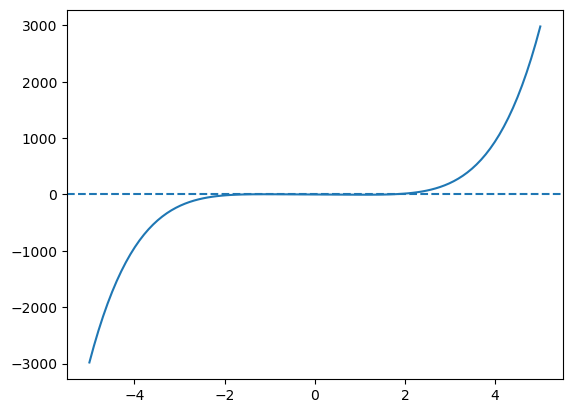

In [17]:
# 5.7
# (a)
def f(x):
    return x ** 5 - x ** 3 - 4 * x


def fprime(x):
    return 5 * x ** 4 - 3 * x ** 2 - 4


_, history = newton(f, fprime, 1)
print(history)

print(np.roots([1, 0, -1, 0, -4, 0]))


x = np.linspace(-5, 5, 100)
plt.plot(x, f(x))
plt.axhline(linestyle='--')

In [18]:
# 5.8
def fa(x):
    return np.acos(-1 / (1 + np.exp(-2 * x)))

print(fixed_point(fa, 3))

def fb(x):
    return .5 * np.log(-1 / (1 + 1 / np.cos(x)))

print(fixed_point(fb, 3))


def f(x):
    return np.cos(x) + 1 / (1 + np.exp(- 2 * x))

def fprime(x):
    return - np.sin(x) - 1 / (1 + np.exp(- 2 * x)) ** 2 * np.exp(-2 * x) * (-2)

_, history = newton(f, fprime, 3)
print(history)

(np.float64(3.076421163400085), array([0.071256, 0.004829, 0.000315, 0.00002 , 0.000001, 0.      ,
       0.      ]))
(np.float64(nan), array([0.702819, 1.956212]))
[[ 3.        0.007535 -0.136187  0.055327]
 [ 3.055327  0.001504 -0.08174   0.018404]
 [ 3.073732  0.000167 -0.063549  0.002633]
 [ 3.076365  0.000003 -0.060944  0.000056]
 [ 3.076421  0.       -0.060889  0.      ]]


C:\Users\chuny\AppData\Local\Temp\ipykernel_5812\1324781523.py:8: RuntimeWarning: invalid value encountered in log
  return .5 * np.log(-1 / (1 + 1 / np.cos(x)))


In [19]:
# 5.9
def g(x):
    return 1 + .5 * np.sin(x)

print(fixed_point(g, 0)[0])


def f(x):
    return 1 - x + .5 * np.sin(x)


def fprime(x):
    return - 1 + .5 * np.cos(x)

_, history = newton(f, fprime, 0)
print(history)

opt.root_scalar(f, fprime=fprime, x0=0, method='newton')

1.4987011332478908
[[ 0.        1.       -0.5       2.      ]
 [ 2.       -0.545351 -1.208073 -0.451422]
 [ 1.548578 -0.048701 -0.988892 -0.049248]
 [ 1.49933  -0.000606 -0.964297 -0.000628]
 [ 1.498701 -0.       -0.963984 -0.      ]]


      converged: True
           flag: converged
 function_calls: 12
     iterations: 6
           root: 1.4987011335178484
         method: newton

In [20]:
# 5.10
def f(x):
    return np.tan(x) * (x ** 2 - 1)  - 2 * x

for x0 in np.exp(range(-10, 1)):
    print(opt.root_scalar(f, x0=x0, method='newton').root)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
6.584620042564173


In [21]:
# 5.11
def f(x):
    return np.tan(x) * np.tanh(x) + 1

for x0 in np.exp(range(-10, 5)):
    print(opt.root_scalar(f, x0=x0, method='newton').root)

-11010.496852668828
-4051.8691249674366
-1488.3295196381646
-548.9933162148163
-200.2765316663493
-74.61282552275759
-27.488935718910692
-8.639379766044119
-2.3470455664870875
-8.639379766044119
2.347045566487087
2.3470455664870875
5.4977703674377345
18.06415775814131
52.621676947629034


In [22]:
# 5.12
def f(x):
    return 1000 - np.log(np.cosh(x * np.sqrt(9.8065 * .00341))) / .00341


opt.root_scalar(f, x0=1)

      converged: True
           flag: converged
 function_calls: 8
     iterations: 4
           root: 22.4364420867071
         method: newton

In [23]:
# 5.16
def nth_root_newton(n, y, x0):
    def f(x):
        return x ** n - y

    def fprime(x):
        return n * x ** (n-1)

    x, history = newton(f, fprime, x0)
    return x, history


print(nth_root_newton(3, 3, x0=complex(-1, 1)))

((-0.721124786014365+1.2490247669991172j), array([[-1.      +1.j      , -1.      +2.j      ,  0.      -6.j      ,
         0.333333+0.166667j],
       [-0.666667+1.166667j, -0.574074-0.032407j, -2.75    -4.666667j,
        -0.058961+0.088271j],
       [-0.725628+1.254938j,  0.046236+0.005947j, -3.144997-5.463706j,
         0.004476-0.005886j],
       [-0.721151+1.249052j,  0.00023 +0.00006j , -3.120214-5.404534j,
         0.000027-0.000027j],
       [-0.721125+1.249025j,  0.      +0.j      , -3.120126-5.404216j,
         0.      -0.j      ]]))


In [24]:
def muller(f, x0, x1, x2):
    for _ in range(3):
        fx0, fx1, fx2 = f(x0), f(x1), f(x2)
        A = np.vander([x0, x1, x2], increasing=True)
        b = [fx0, fx1, fx2]
        r1, r2 = Polynomial(la.solve(A, b)).roots()
        r = r1 if abs(x2 - r1) < abs(x2 - r2) else r2
        x0, x1, x2 = x1, x2, r
        fx0, fx1, fx2 = fx1, fx2, f(r)
    return x2


def nth_root_muller(n, y, x0, x1, x2):
    def f(x):
        return x ** n - y
    return muller(f, x0, x1, x2)


nth_root_muller(3, 3, x2=complex(-1, 1), x1=1, x0=2)


np.complex128(-0.721756505408445+1.247719860645189j)

In [25]:
def f(x, a, b, c):
    return np.array([
        sum(x) + a,
        x[0] * x[1] + x[1] * x[2] + x[0] * x[2] - b,
        x[0] * x[1] * x[2] + c,
    ])

def jac(x, a, b, c):
    return np.array([
        [1, 1, 1],
        [x[1]+x[2], x[0]+x[2], x[0]+x[1]],
        [x[1]*x[2], x[0]*x[2], x[0]*x[1]],
    ])


def n_newton(f, jac, x, args=(), n=1000, tol=1e-4):
    history = []
    for _ in range(n):
        h = la.solve(jac(x, *args), -f(x, *args))
        history.append(np.hstack([x, [la.norm(h, ord=np.inf)]]))
        if la.norm(h) < tol:
            break
        x += h
    return x, np.array(history)


_, history = n_newton(f, jac, [1, 2, 3], args=(-3, 3, -1))
print(history)

# error = history[:, -1]
# plt.plot(error)
# plt.plot(np.exp((np.log(error[1:]) - 2 * np.log(error[:-1]))))


[[ 1.        2.        3.        4.      ]
 [ 1.        3.       -1.        1.      ]
 [ 1.        2.        0.        0.5     ]
 [ 1.        1.5       0.5       0.25    ]
 [ 1.        1.25      0.75      0.125   ]
 [ 1.        1.125     0.875     0.0625  ]
 [ 1.        1.0625    0.9375    0.03125 ]
 [ 1.        1.03125   0.96875   0.015625]
 [ 1.        1.015625  0.984375  0.007813]
 [ 1.        1.007813  0.992188  0.003906]
 [ 1.        1.003906  0.996094  0.001953]
 [ 1.        1.001953  0.998047  0.000977]
 [ 1.        1.000977  0.999023  0.000488]
 [ 1.        1.000488  0.999512  0.000244]
 [ 1.        1.000244  0.999756  0.000122]
 [ 1.        1.000122  0.999878  0.000061]]


[[-0.5       1.4       0.444685]
 [-0.055315  1.028067  0.055175]
 [-0.00014   1.000157  0.000157]
 [-0.        1.        0.      ]]


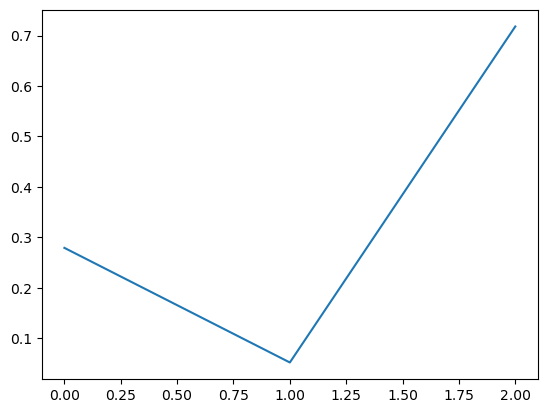

In [26]:
# 5.18
# (a)
def f(x):
    return np.array([
        (x[0] + 3) * (x[1] ** 3 - 7) + 18,
        np.sin(x[1] * np.exp(x[0]) - 1),
    ])

def jac(x):
    return np.array([
        [x[1] ** 3 - 7, (x[0] + 3) * 3 * x[1] ** 2],
        [
            np.cos(x[1] * np.exp(x[0]) - 1) * x[1] * np.exp(x[0]),
            np.cos(x[1] * np.exp(x[0]) - 1) * np.exp(x[0]),
        ],
    ])


_, history = n_newton(f, jac, x=[-.5, 1.4])
print(history)
error = history[:, -1]
# plt.plot(error)
plt.plot(np.exp((np.log(error[1:]) - 2 * np.log(error[:-1]))))

In [27]:
# (b)
x = [-.5, 1.4]
B = jac(x)
_, history = broyden(f, x, B=B)
print(history)
# error = history[:, -1]
# # plt.plot(error)
# plt.plot(np.exp((np.log(error[1:]) - 2 * np.log(error[:-1]))))

[[-0.5       1.4       0.579723]
 [-0.055315  1.028067  0.062428]
 [ 0.00051   1.000124  0.000745]
 [-0.000234  1.000077  0.000203]
 [-0.000041  1.000014  0.000043]
 [-0.        1.        0.      ]]


In [28]:
# 5.19
def f(x):
    return np.array([
        4 * x[0] * x[1] - x[0],
        - x[0] * x[1] + 1 - x[1] ** 2,
    ])


def jac(x):
    return np.array([
        [4 * x[1] - 1, 4 * x[0]],
        [-x[1], -x[0] - 2 * x[1]],
    ])


print(n_newton(f, jac, [1, 1]))

print(n_newton(f, jac, [100, 0]))


(array([0., 1.]), array([[1., 1., 1.],
       [0., 1., 0.]]))
(array([3.75, 0.25]), array([[100.      ,   0.      ,  96.      ],
       [  4.      ,   0.01    ,   0.23883 ],
       [  3.980494,   0.24883 ,   0.230353],
       [  3.75014 ,   0.249932,   0.00014 ],
       [  3.75    ,   0.25    ,   0.      ]]))


In [29]:
# 5.20
# (a)
def f(x):
    return np.array([
        x[0] / np.tan(x[0]) + x[1],
        x[0] ** 2 + x[1] ** 2 - 3.5 ** 2, 
    ])


opt.root(f, x0=[1, 1])


 message: The solution converged.
 success: True
  status: 1
     fun: [-1.995e-10  2.452e-11]
       x: [ 2.390e+00  2.557e+00]
  method: hybr
    nfev: 27
    fjac: [[-8.889e-01  4.582e-01]
           [-4.582e-01 -8.889e-01]]
       r: [ 1.152e+01  6.445e+00 -3.162e+00]
     qtf: [-1.292e-07 -4.769e-08]

[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[0. 0. 0.]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[ 8.485281  8.485281 27.      ]
[ 8.485281  8.485281 27.      ]
[ 8.485281  8.485281 27.      ]
[ 8.485281  8.485281 27.      ]
[ 8.485281  8.485281 27.      ]
[ 8.485281  8.485281 27.      ]
[ 8.485281  8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[0. 0. 0.]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[-8.485281 -8.485281 27.      ]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 

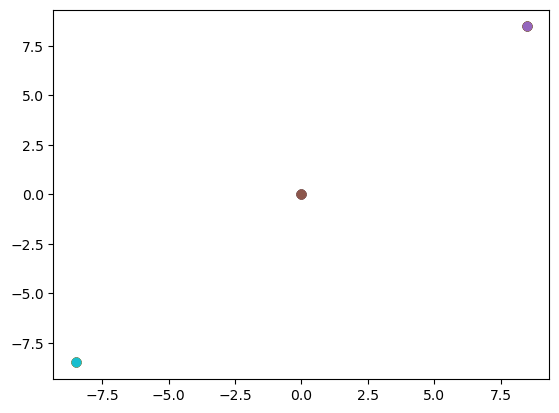

In [32]:
# 5.21
def f(x):
    return np.array([
        x[1] - x[0],
        28 * x[0] - x[1] - x[0] * x[2],
        x[0] * x[1] - 8 / 3 * x[2],
    ])


for x in np.linspace(-1000, 1000, 5):
    for y in np.linspace(-1000, 1000, 5):
        for z in np.linspace(-1000, 1000, 5):
            r = opt.root(f, x0=[x, y, z]).x
            print(r)
            plt.scatter(*r[:-1])

In [46]:
# 5.22
def n_fixed_point(f, x0, x_true=None, n=100, tol=1e-6):
    history = []
    for _ in range(n):
        x1 = f(x0)
        if np.isnan(x1).any():
            break
        h = la.norm(x1 - (x_true if x_true else x0))
        history.append(np.hstack([x0, [h]]))
        if h < tol:
            break

        x0 = x1
    return x1, np.array(history)


def g(x):
    return np.array([
        - np.cos(x[0]) / 81 + x[1] ** 2 / 9 + np.sin(x[2]) / 3,
        np.sin(x[0]) / 3 + np.cos(x[2]) / 3,
        - np.cos(x[0]) / 9 + x[1] / 3 + np.sin(x[2]) / 6,
    ])


n_fixed_point(g, x0=[1, 2, 3])

(array([0.      , 0.333334, 0.      ]),
 array([[ 1.      ,  2.      ,  3.      ,  3.175228],
        [ 0.484814, -0.049507,  0.630153,  0.85589 ],
        [ 0.185772,  0.42466 , -0.016598,  0.191461],
        [ 0.002372,  0.394856,  0.029588,  0.06228 ],
        [ 0.014839,  0.333978,  0.025438,  0.022299],
        [ 0.008528,  0.338172,  0.004466,  0.007281],
        [ 0.00185 ,  0.336173,  0.002361,  0.002591],
        [ 0.000998,  0.333949,  0.00134 ,  0.00108 ],
        [ 0.000492,  0.333666,  0.000429,  0.000441],
        [ 0.000168,  0.333497,  0.000182,  0.000174],
        [ 0.000073,  0.333389,  0.000085,  0.000073],
        [ 0.000032,  0.333358,  0.000033,  0.000031],
        [ 0.000013,  0.333344,  0.000014,  0.000013],
        [ 0.000005,  0.333338,  0.000006,  0.000005],
        [ 0.000002,  0.333335,  0.000002,  0.000002],
        [ 0.000001,  0.333334,  0.000001,  0.000001]]))

In [47]:
def g_jac(x):
    return np.array([
        [np.sin(x[0]) / 81, 2 * x[1] / 9, np.cos(x[2]) / 3],
        [np.cos(x[0]) / 3, 0, - np.sin(x[2]) / 3],
        [np.sin(x[0]) / 9, 1 / 3, np.cos(x[2]) / 6],
    ])

J = g_jac([0, 1/3, 0])
np.abs(la.eig(J)[0]).max()

np.float64(0.41612582329476744)

In [48]:
# (b)
def f(x):
    return x - g(x)

def jac(x):
    return np.eye(len(x)) - g_jac(x)


_, history = n_newton(f, jac, [1, 2, 3])
print(history)

[[ 1.        2.        3.        2.656428]
 [ 0.456965 -0.02235   0.343572  0.468204]
 [-0.011239  0.35953  -0.000705  0.026226]
 [-0.000086  0.333305 -0.00002   0.000086]]


In [54]:
# 5.23
def f(x):
    return np.array([
        16 * x[0] ** 4 + 16 * x[1] ** 4 + x[2] ** 4 - 16,
        x[0] ** 2 + x[1] ** 2 + x[2] ** 2 - 3,
        x[0] ** 3 - x[1],
    ])


def jac(x):
    return np.array([
        [64 * x[0] ** 3, 64 * x[1] ** 3, 4 * x[2] ** 3],
        [2 * x[0], 2 * x[1], 2 * x[2]],
        [3 * x[0] ** 2, -1, 0],
    ])


_, history = n_newton(f, jac, [1, 1, 1])
print(history)

opt.root(fun=f, jac=jac, x0=[1, 1, 1])

[[1.       1.       1.       0.283333]
 [0.929167 0.7875   1.283333 0.094324]
 [0.887075 0.693176 1.320865 0.015981]
 [0.878244 0.677195 1.33061  0.000437]
 [0.877966 0.676757 1.330855 0.      ]]


 message: The solution converged.
 success: True
  status: 1
     fun: [ 4.318e-10  8.047e-11 -4.877e-11]
       x: [ 8.780e-01  6.768e-01  1.331e+00]
  method: hybr
    nfev: 13
    njev: 1
    fjac: [[-9.975e-01 -5.219e-02 -4.676e-02]
           [-2.824e-02 -3.113e-01  9.499e-01]
           [ 6.413e-02 -9.489e-01 -3.090e-01]]
       r: [-5.101e+01 -2.536e+01 -4.479e+00 -2.283e+00 -7.563e-01
           -1.647e+00]
     qtf: [ 9.724e-09 -4.174e-09 -3.506e-10]

In [55]:
broyden(f, [1, 1, 1], B=jac([1, 1, 1]))

(array([0.877966, 0.676757, 1.330855]),
 array([[1.      , 1.      , 1.      , 0.361181],
        [0.929167, 0.7875  , 1.283333, 0.066519],
        [0.903512, 0.727254, 1.29504 , 0.071293],
        [0.878612, 0.675559, 1.337351, 0.009128],
        [0.879107, 0.678438, 1.328702, 0.002422],
        [0.878237, 0.677045, 1.330483, 0.000534],
        [0.877981, 0.676751, 1.330848, 0.000017],
        [0.877967, 0.676752, 1.330857, 0.000004],
        [0.877966, 0.676756, 1.330856, 0.000001],
        [0.877966, 0.676757, 1.330855, 0.      ]]))

In [ ]:
# 5.28
def newton_matrix_inverse(A, X, n=1000, tol=1e-6):
    for _ in range(n):
        h = X @ (np.eye(len(A)) - A @ X)
        if la.norm(h, ord=np.inf) < tol:
            break
        X += h

    return X

np.random.seed(0)
for _ in range(10): 
    A = np.random.random((5, 5))
    A_inv = la.inv(A)
    A_inv_newton = newton_matrix_inverse(A, A.T / la.norm(A, ord=1) / la.norm(A, ord=np.inf))
    print(np.allclose(A_inv, A_inv_newton))


True
True
True
True
True
True
True
True
True
True


In [ ]:
# 5.29
def newton_eigenvalue_eigenvector(A, n=1000, tol=1e-6):
    x = np.random.rand(len(A))
    x /= la.norm(x)

    for _ in range(n):
        lam = x @ A @ x
        
        jac = np.vstack([
           np.hstack([A - lam * np.eye(len(A)), -x.reshape(-1, 1)]),
           np.hstack([2 * x, 0]),
        ])
        f = np.hstack([
            A @ x - lam * x,
            x @ x - 1,
        ])
        h = la.solve(jac, -f)
        if la.norm(h) < tol:
            break
        x += h[:-1]

    return lam, x


A = np.random.random((5, 5))
print(newton_eigenvalue_eigenvector(A))

print(la.eig(A))


(5,)
(np.float64(2.1819144323788553), array([0.350028, 0.227801, 0.587329, 0.5902  , 0.363725]))
(array([ 2.181914+0.j      , -0.027814+0.533922j, -0.027814-0.533922j,
       -0.134182+0.19854j , -0.134182-0.19854j ]), array([[ 0.350028+0.j      , -0.028876+0.24936j , -0.028876-0.24936j ,
        -0.480562+0.197137j, -0.480562-0.197137j],
       [ 0.227801+0.j      , -0.468071+0.286971j, -0.468071-0.286971j,
        -0.035489-0.336575j, -0.035489+0.336575j],
       [ 0.587329+0.j      ,  0.681346+0.j      ,  0.681346-0.j      ,
        -0.109844+0.169959j, -0.109844-0.169959j],
       [ 0.5902  +0.j      ,  0.032678+0.064057j,  0.032678-0.064057j,
         0.738988+0.j      ,  0.738988-0.j      ],
       [ 0.363725+0.j      , -0.173347-0.368905j, -0.173347+0.368905j,
         0.168916-0.008273j,  0.168916+0.008273j]]))
